# Test: 3-Step Grid Search with Real Representations

Verifies that `run_3step_grid_search.py` works correctly with real stimulus
representations (ResNet50 layer4) and `run_model_core` + `ThreeRegimeNoise`.

1. Load experiment data & encode stimuli
2. Generate toy sequences
3. Run a single (sigma0, sigma1, sigma2) triple
4. Compute d' per ISI
5. Run a small 3×3×3 grid
6. ISI decay curves
7. Cross-check against `run_mc_dprime()`

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import types
import sys

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'  # the only attr actually used
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock


# project paths
sys.path.insert(0, os.path.abspath('..'))
sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

import torch

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set

from utls.encoders import *
from utls.runners_v2 import run_model_core, make_noise_schedule
from utls.runners_utils import load_experiment_data, build_encoder, encode_stimuli
from utls.toy_experiments import make_high_diversity_sequences
from utls.roc_utils import roc_from_arrays
from utls.analysis_helpers import auroc_to_dprime

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
print('Imports OK')

Imports OK


## 1. Load experiment data & encode stimuli

In [2]:
which_task = 0   # env-sounds
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = \
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)

print(f'Task: {task_name} ({hr_task_name})')
print(f'Sequences: {len(exp_list)}, stimuli: {len(all_files)}')

Task: env-sounds (Industrial and Nature)
Sequences: 104, stimuli: 80


In [3]:
encoder_cfg = dict(
    encoder_type='resnet50',
    model_name='resnet50',
    task='word_speaker_audioset',
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=False,
    device='cuda',
    layer='layer4',
)

print('Building encoder: resnet50 / layer4 ...')
encoder = build_encoder(encoder_cfg)

print(f'Encoding {len(all_files)} stimuli ...')
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}')
print(f'Any NaN: {torch.isnan(X0).any().item()}')

Building encoder: resnet50 / layer4 ...
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
### WARNING: UNABLE TO FIND JSIN AUDIO TRAINING DATASET FILES. IF TRAINING AUDIO MODELS, CHANGE PATH SPECIFIED IN analysis_scripts/default_paths.py. MODELS CAN BE LOADED AND TESTED WITHOUT THESE FILES. ###
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoding 80 stimuli ...
X0 shape: torch.Size([80, 186368])
Any NaN: False


## 2. Generate toy sequences

In [4]:
ISI_VALUES = [0, 1, 2, 4, 8, 16, 32, 64]
N_SEQUENCES = 30
SEQ_LENGTH = 120

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f'Stimulus pool: {len(stimulus_pool)} unique stimuli')

experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES,
    n_sequences=N_SEQUENCES,
    length=SEQ_LENGTH,
    min_pairs_per_isi=4,
    seed=43,
)

print(f'{len(experiment_list)} sequences, {len(experiment_list[0])} trials each')

Aggregate ISI usage across all sequences:
  ISI -1: 1200
  ISI 0: 326
  ISI 1: 276
  ISI 2: 314
  ISI 4: 302
  ISI 8: 310
  ISI 16: 292
  ISI 32: 292
  ISI 64: 288
30 sequences, 120 trials each


## 3. Run a single (sigma0, sigma1, sigma2) triple

In [6]:
s0, s1, s2 = 20.3, 5.1, 3
t_step = 5
metric = 'cosine'

schedule = make_noise_schedule('three-regime', {
    'sigma0': s0, 'sigma1': s1, 'sigma2': s2, 't_step': t_step,
})

print(f'Running single trial: sigma0={s0}, sigma1={s1}, sigma2={s2}, t_step={t_step}')
t0 = time.perf_counter()

run = run_model_core(
    sigma0=s0,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list[:5],
    noise_schedule=schedule,
    metric=metric,
    seed=42,
)

elapsed = time.perf_counter() - t0
print(f'Done in {elapsed:.2f}s')
print(f'Hits: {len(run["hits"])}, FAs: {len(run["fas"])}')
print(f'ISI hit dists keys: {sorted(run["isi_hit_dists"].keys())}')
for isi, vals in sorted(run['isi_hit_dists'].items()):
    print(f'  ISI={isi}: {len(vals)} hits')

Running single trial: sigma0=20.3, sigma1=5.1, sigma2=3, t_step=5
Done in 4.92s
Hits: 200, FAs: 395
ISI hit dists keys: [1, 2, 3, 5, 9, 17, 33, 65]
  ISI=1: 29 hits
  ISI=2: 21 hits
  ISI=3: 27 hits
  ISI=5: 27 hits
  ISI=9: 25 hits
  ISI=17: 27 hits
  ISI=33: 21 hits
  ISI=65: 23 hits


## 4. Compute d' per ISI (MC repetitions)

In [15]:
N_MC = 3
runner_isi_values = [isi + 1 for isi in ISI_VALUES]

schedule = make_noise_schedule('three-regime', {
    'sigma0': s0, 'sigma1': s1, 'sigma2': s2, 't_step': t_step,
})

all_isi_hits = defaultdict(list)
all_fas = []

print(f'Running {N_MC} MC reps ...')
for rep in range(N_MC):
    run = run_model_core(
        sigma0=s0,
        X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list[:5],
        noise_schedule=schedule,
        metric=metric,
        seed=42 * 10_000 + rep,
    )
    for risi in runner_isi_values:
        all_isi_hits[risi].extend(run['isi_hit_dists'].get(risi, []))
    all_fas.extend(run['fas'])

fas_arr = np.array(all_fas, dtype=float)
score_type = 'distance' if metric != 'loglikelihood' else 'likelihood'

print(f'\nResults (sigma0={s0}, sigma1={s1}, sigma2={s2}):')
print(f'Total FAs: {len(fas_arr)}')

for exp_isi, risi in zip(ISI_VALUES, runner_isi_values):
    hits_raw = all_isi_hits.get(risi, [])
    if len(hits_raw) < 3:
        print(f'  ISI={exp_isi}: too few hits ({len(hits_raw)})')
        continue
    hits_scores = np.array([s for s, t in hits_raw], dtype=float)
    roc = roc_from_arrays(hits_scores, fas_arr, score_type=score_type)
    if roc is not None:
        fpr, tpr, auc_val = roc
        dp = auroc_to_dprime(auc_val)
    else:
        auc_val, dp = np.nan, np.nan
    print(f"  ISI={exp_isi}: n_hits={len(hits_raw)}, AUC={auc_val:.4f}, d'={dp:.4f}")

Running 3 MC reps ...

Results (sigma0=20.3, sigma1=5.1, sigma2=3):
Total FAs: 1185
  ISI=0: n_hits=87, AUC=0.9742, d'=2.7538
  ISI=1: n_hits=63, AUC=0.9476, d'=2.2937
  ISI=2: n_hits=81, AUC=0.8360, d'=1.3836
  ISI=4: n_hits=81, AUC=0.8112, d'=1.2478
  ISI=8: n_hits=75, AUC=0.7683, d'=1.0369
  ISI=16: n_hits=81, AUC=0.6109, d'=0.3984
  ISI=32: n_hits=63, AUC=0.5500, d'=0.1776
  ISI=64: n_hits=69, AUC=0.5842, d'=0.3006


## 5. Run a small 3x3x3 grid

In [ ]:
# Import run_mc_dprime from the grid search script
sys.path.insert(0, os.path.abspath('../src/model'))
from run_3step_grid_search import run_mc_dprime

sigma0_grid = np.geomspace(0.1, 10.0, 7)
sigma1_grid = np.geomspace(0.01, 10, 8)
sigma2_grid = np.geomspace(0.01, 10.0, 8)

n_mc_grid = 1  # keep small for testing
total = len(sigma0_grid) * len(sigma1_grid) * len(sigma2_grid)
print(f'Running {total} triples (n_mc={n_mc_grid}) ...')

rows = []
t_start = time.perf_counter()

for i, s0 in enumerate(sigma0_grid):
    print(i)
    for s1 in sigma1_grid:
        for s2 in sigma2_grid:
            dp, _ = run_mc_dprime(
                s0, s1, s2,
                X0=X0, name_to_idx=name_to_idx,
                experiment_list=experiment_list[:10],
                t_step=t_step,
                isi_values=tuple(ISI_VALUES),
                n_mc=n_mc_grid,
                seed=42 + int(s0*1000 + s1*100 + s2*10),
                metric=metric,
            )
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = dp.get(isi, np.nan)
            rows.append(row)

elapsed = time.perf_counter() - t_start
df = pd.DataFrame(rows)
print(f'\nDone in {elapsed:.1f}s ({elapsed/total:.1f}s per triple)')
df

Running 448 triples (n_mc=1) ...
0
1
2
3
4
5
6

Done in 3430.0s (7.7s per triple)


,sigma0,sigma1,sigma2,dprime_isi0,dprime_isi1,dprime_isi2,dprime_isi4,dprime_isi8,dprime_isi16,dprime_isi32,dprime_isi64
0,0.1,0.01,0.010000,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357
1,0.1,0.01,0.026827,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357
2,0.1,0.01,0.071969,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357,6.722357,2.997621
3,0.1,0.01,0.193070,6.722357,6.722357,6.722357,6.722357,5.202489,1.773302,0.277454,0.090704
4,0.1,0.01,0.517947,6.722357,6.722357,6.722357,3.807326,0.032494,-0.108653,0.042729,-0.041588
...,...,...,...,...,...,...,...,...,...,...,...
443,10.0,10.00,0.193070,4.098774,0.256652,-0.047421,-0.208307,0.085808,-0.173552,0.200444,-0.011767
444,10.0,10.00,0.517947,4.098774,0.256758,-0.047421,-0.209107,0.083644,-0.173461,0.200350,-0.011866
445,10.0,10.00,1.389495,4.098774,0.256546,-0.047336,-0.210798,0.074905,-0.173823,0.200161,-0.012365
446,10.0,10.00,3.727594,4.098774,0.256970,-0.046574,-0.208930,0.070079,-0.173100,0.201105,-0.012764


## 6. ISI decay curves

448


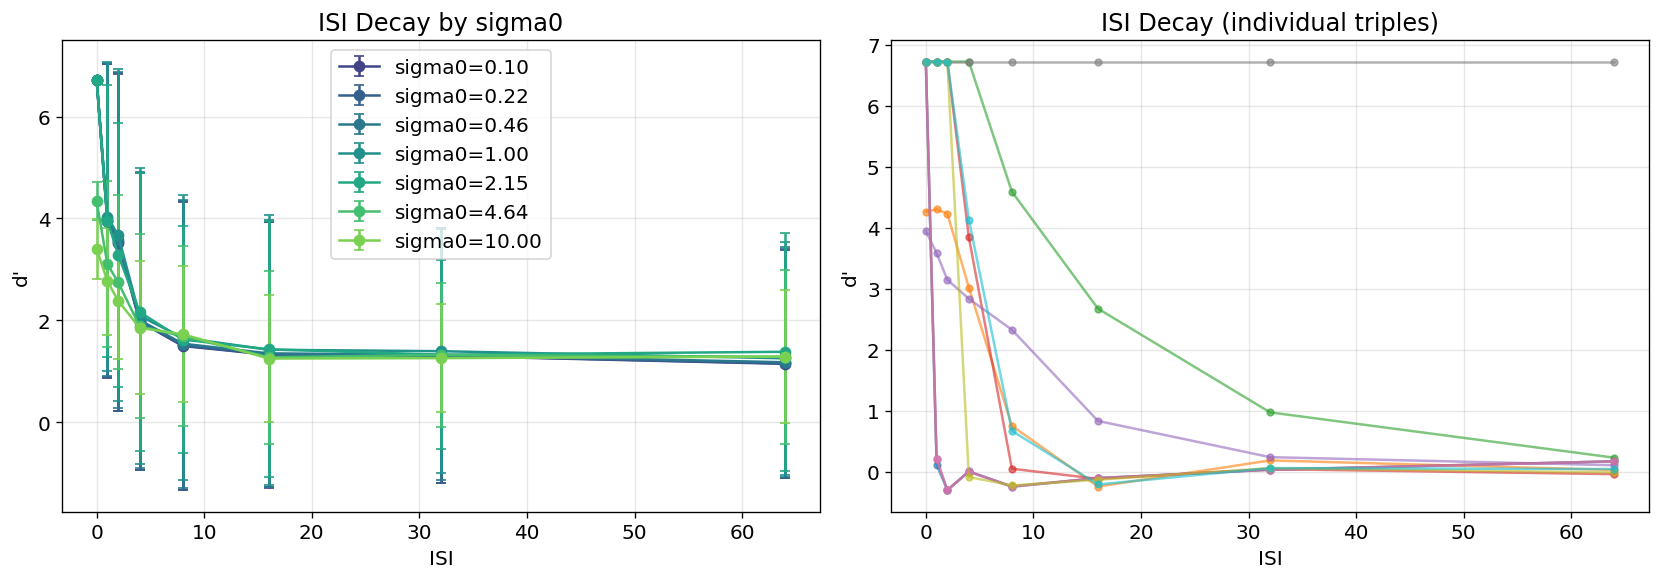

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot error bars (STD) for each ISI value per sigma0 on the left plot



# --- Left: ISI decay averaged over sigma1, sigma2 per sigma0 ---
ax = axes[0]
colors_s0 = plt.cm.viridis(np.linspace(0.2, 0.8, len(sigma0_grid)))

for s0, color in zip(sigma0_grid, colors_s0):
    sub = df[df['sigma0'] == s0]
    means = [sub[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    stds = [sub[f'dprime_isi{isi}'].std() for isi in ISI_VALUES]
    # Draw the line with error bars (std)
    ax.errorbar(ISI_VALUES, means, yerr=stds, marker='o', color=color, label=f'sigma0={s0:.2f}', capsize=3, linestyle='-')

ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('ISI Decay by sigma0')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: individual triple curves (sample a few) ---
ax = axes[1]
samples = min(10, len(df))
sample = df.sample(n=samples, random_state=44)
print(len(df))

for _, row in sample.iterrows():
    dps = [row[f'dprime_isi{isi}'] for isi in ISI_VALUES]
    label = f's0={row["sigma0"]:.2f} s1={row["sigma1"]:.2f} s2={row["sigma2"]:.2f}'
    ax.plot(ISI_VALUES, dps, marker='o', alpha=0.6, markersize=4, label=label)
    

ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('ISI Decay (individual triples)')
if samples < 10:
    ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

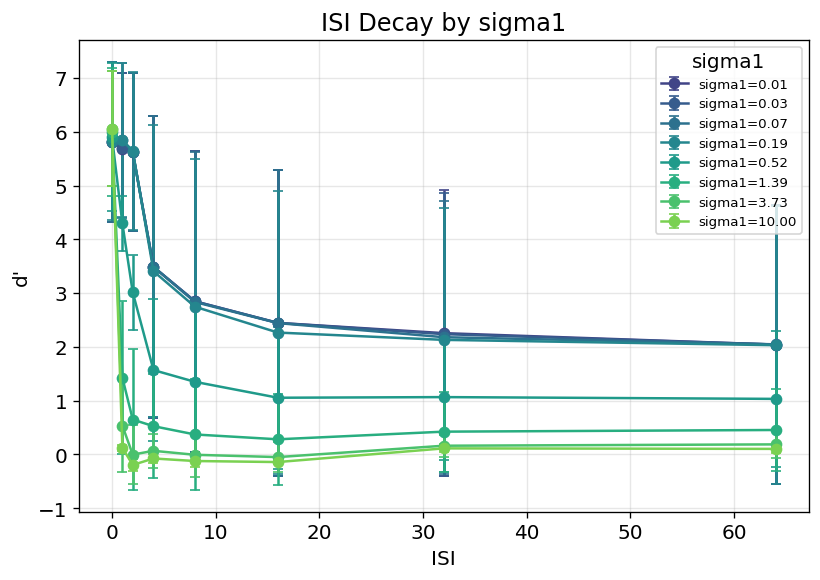

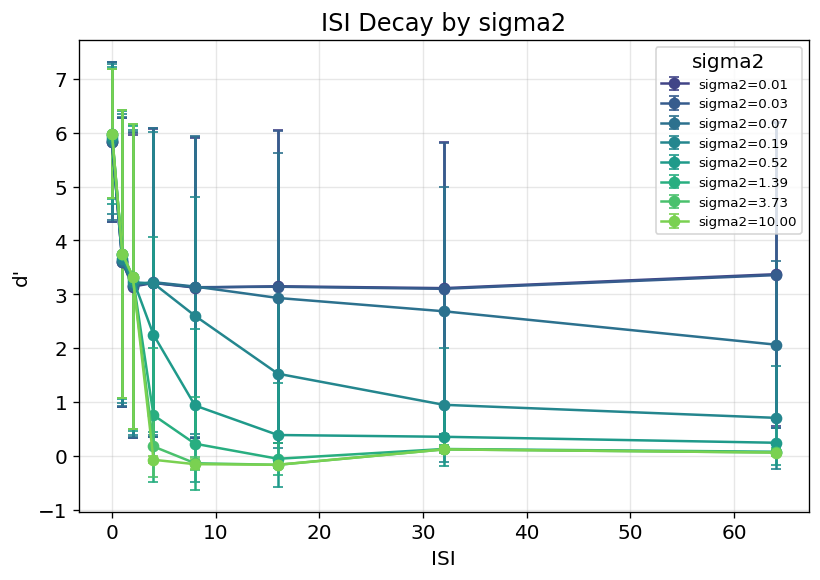

In [16]:
# --- ISI Decay by Sigma1 ---
fig1, ax1 = plt.subplots(figsize=(7, 5))
# Use the same colormap as before (viridis) for consistency with the "by sigma0" graph
colors_s1 = plt.cm.viridis(np.linspace(0.2, 0.8, len(sigma1_grid)))
for s1, color in zip(sigma1_grid, colors_s1):
    sub = df[df['sigma1'] == s1]
    means = [sub[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    stds = [sub[f'dprime_isi{isi}'].std() for isi in ISI_VALUES]
    ax1.errorbar(ISI_VALUES, means, yerr=stds, marker='o', color=color, label=f'sigma1={s1:.2f}', capsize=3, linestyle='-')
ax1.set_xlabel('ISI')
ax1.set_ylabel("d'")
ax1.set_title('ISI Decay by sigma1')
ax1.legend(fontsize=8, title='sigma1')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- ISI Decay by Sigma2 ---
fig2, ax2 = plt.subplots(figsize=(7, 5))
# Use the same colormap as before (viridis) for consistency with the other graphs
colors_s2 = plt.cm.viridis(np.linspace(0.2, 0.8, len(sigma2_grid)))
for s2, color in zip(sigma2_grid, colors_s2):
    sub = df[df['sigma2'] == s2]
    means = [sub[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    stds = [sub[f'dprime_isi{isi}'].std() for isi in ISI_VALUES]
    ax2.errorbar(ISI_VALUES, means, yerr=stds, marker='o', color=color, label=f'sigma2={s2:.2f}', capsize=3, linestyle='-')
ax2.set_xlabel('ISI')
ax2.set_ylabel("d'")
ax2.set_title('ISI Decay by sigma2')
ax2.legend(fontsize=8, title='sigma2')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
from utls.runners_utils import *

human_curve = compute_human_curve(human_runs, is_multi, None)
print(human_curve)

# Compute the average human d' across ISIs (or use the human_curve as target)
target_human_curve = human_curve  # human_curve from previous cell

def distance_to_human_curve(row, target_curve, isi_values):
    model_curve = np.array([row[f'dprime_isi{isi}'] for isi in isi_values])
    # If model_curve or target_curve have different length, pad with nan if needed
    min_len = min(len(model_curve), len(target_curve))
    return np.linalg.norm(model_curve[:min_len] - target_curve[:min_len])

# # Compute the distance for each row (hyperparameter combination)
# df['dist_to_human'] = df.apply(lambda row: distance_to_human_curve(row, target_human_curve, ISI_VALUES), axis=1)

# # Find the row(s) with minimal distance
# top10 = df.nsmallest(10, 'dist_to_human').reset_index(drop=True)
# best_hyperparams = top10.loc[0]

# print("Top 10 closest models (d' curves to human):")
# display(top10[[f'dprime_isi{isi}' for isi in ISI_VALUES] + ['sigma0', 'sigma1', 'sigma2', 'dist_to_human']])

# print("\nBest hyperparameters to match human performance:")
# display(best_hyperparams)

# print("\nCorresponding ISI d' model performance:")
# display(best_hyperparams[[f'dprime_isi{isi}' for isi in ISI_VALUES]])

# print(f"\nL2 distance to human curve: {best_hyperparams['dist_to_human']:.4f}")

# # Plot the top 10 models and human curve
# plt.figure(figsize=(8, 6))

# # Model curves
# for i, row in top10.iterrows():
#     curve = [row[f'dprime_isi{isi}'] for isi in ISI_VALUES]
#     label = f"Model {i+1}: σ0={row['sigma0']:.3g}, σ1={row['sigma1']:.3g}, σ2={row['sigma2']:.3g}"
#     plt.plot(ISI_VALUES, curve, label=label, alpha=0.7, lw=2 if i==0 else 1)

# # Human curve (marked in black, wider)
# plt.plot(ISI_VALUES, target_human_curve[:len(ISI_VALUES)], 'ko-', label='Human', lw=3, markersize=8, zorder=10)

# plt.xlabel('ISI')
# plt.ylabel("d'")
# plt.title('d\' Curve: Top 10 Closest Models vs Human')
# plt.legend(fontsize=8)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()




/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


[3.45431377 3.02981819 2.35418552 2.12608788 1.97633419 1.88956019
 1.76769441 1.5619915 ]


In [5]:
sigma0_grid = np.geomspace(0.1, 10.0, 7)
sigma1_grid = np.geomspace(0.01, 10, 8)
sigma2_grid = np.geomspace(0.01, 10.0, 8)

print("sigma0 grid:", sigma0_grid)
print("sigma1 grid:", sigma1_grid)
print("sigma2 grid:", sigma2_grid)

sigma0 grid: [ 0.1         0.21544347  0.46415888  1.          2.15443469  4.64158883
 10.        ]
sigma1 grid: [ 0.01        0.02682696  0.07196857  0.19306977  0.51794747  1.38949549
  3.72759372 10.        ]
sigma2 grid: [ 0.01        0.02682696  0.07196857  0.19306977  0.51794747  1.38949549
  3.72759372 10.        ]


In [21]:
# Import run_mc_dprime from the grid search script
sys.path.insert(0, os.path.abspath('../src/model'))
from run_3step_grid_search import run_mc_dprime

t_step = 5
metric = 'cosine'
# Get best hyperparameters from previous sweep
# best_sigma0 = float(best_hyperparams['sigma0'])
# best_sigma1 = float(best_hyperparams['sigma1'])
# best_sigma2 = float(best_hyperparams['sigma2'])

# Make a small grid around the best values (3x3x3), geometric steps
def centered_geom_grid(center, n=3, factor=2):
    # e.g., factor=2 creates logspace grid [center/f, center, center*f]
    return np.geomspace(center / factor, center * factor, n)

sigma0_grid = [10.3]#centered_geom_grid(10.1, n=4, factor=1.05)
sigma1_grid = centered_geom_grid(2.4, n=5, factor=1.1)
sigma2_grid = centered_geom_grid(0.45, n=5, factor=1.4)

print("Refined sigma0 grid:", sigma0_grid)
print("Refined sigma1 grid:", sigma1_grid)
print("Refined sigma2 grid:", sigma2_grid)

n_mc_grid = 1  # still keep small for testing
total = len(sigma0_grid) * len(sigma1_grid) * len(sigma2_grid)
print(f'Running {total} triples (n_mc={n_mc_grid}) on next 10 experiments...')

rows = []
t_start = time.perf_counter()

for i, s0 in enumerate(sigma0_grid):
    print(f"sigma0 idx {i} value {s0:.4g}")
    for s1 in sigma1_grid:
        for s2 in sigma2_grid:
            dp, _ = run_mc_dprime(
                s0, s1, s2,
                X0=X0, name_to_idx=name_to_idx,
                experiment_list=experiment_list[10:20],  # next 10 experiments
                t_step=t_step,
                isi_values=tuple(ISI_VALUES),
                n_mc=n_mc_grid,
                seed=47 + int(s0*1000 + s1*100 + s2*10),
                metric=metric,
            )
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = dp.get(isi, np.nan)
            rows.append(row)

elapsed    = time.perf_counter() - t_start
df_refined = pd.DataFrame(rows)
print(f'\nDone in {elapsed:.1f}s ({elapsed/total:.1f}s per triple)');
df_refined

Refined sigma0 grid: [10.3]
Refined sigma1 grid: [2.18181818 2.28831021 2.4        2.51714124 2.64      ]
Refined sigma2 grid: [0.32142857 0.38031941 0.45       0.53244718 0.63      ]
Running 25 triples (n_mc=1) on next 10 experiments...
sigma0 idx 0 value 10.3

Done in 191.5s (7.7s per triple)


,sigma0,sigma1,sigma2,dprime_isi0,dprime_isi1,dprime_isi2,dprime_isi4,dprime_isi8,dprime_isi16,dprime_isi32,dprime_isi64
0,10.3,2.181818,0.321429,4.241126,3.450061,2.617561,2.395588,1.978976,2.340027,2.006188,1.607259
1,10.3,2.181818,0.380319,4.241126,3.472969,2.655574,2.433308,1.990237,2.320767,1.949117,1.399238
2,10.3,2.181818,0.450000,4.430279,3.446330,2.883589,2.191711,2.310764,2.400571,2.199195,1.162748
3,10.3,2.181818,0.532447,4.628034,3.705954,2.468384,2.547078,2.094445,2.112530,1.848580,0.757511
4,10.3,2.181818,0.630000,4.967225,3.227900,2.748320,2.599040,2.085529,1.985467,1.438240,0.649260
5,10.3,2.288310,0.321429,4.399423,3.217652,2.362855,2.065236,1.996295,2.215911,2.084291,1.561446
6,10.3,2.288310,0.380319,4.409477,3.248919,2.388100,2.077796,2.007497,2.204655,2.020733,1.409611
7,10.3,2.288310,0.450000,4.741829,3.339518,2.636329,2.331546,2.170788,2.002390,1.819410,1.235607
8,10.3,2.288310,0.532447,4.463401,3.153698,2.517045,2.353757,1.967101,1.843861,1.763476,1.014232
9,10.3,2.288310,0.630000,4.399423,3.405055,2.443739,2.424545,1.855515,1.977732,1.540575,0.675081


<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4173556/571366361.py:40: SyntaxWarning: invalid escape sequence '\s'
  best_params = f"$\sigma_0$={best_row['sigma0']}, $\sigma_1$={best_row['sigma1']:3f}, $\sigma_2$={best_row['sigma2']:4.2f}"
/tmp/ipykernel_4173556/571366361.py:40: SyntaxWarning: invalid escape sequence '\s'
  best_params = f"$\sigma_0$={best_row['sigma0']}, $\sigma_1$={best_row['sigma1']:3f}, $\sigma_2$={best_row['sigma2']:4.2f}"
/tmp/ipykernel_4173556/571366361.py:40: SyntaxWarning: invalid escape sequence '\s'
  best_params = f"$\sigma_0$={best_row['sigma0']}, $\sigma_1$={best_row['sigma1']:3f}, $\sigma_2$={best_row['sigma2']:4.2f}"


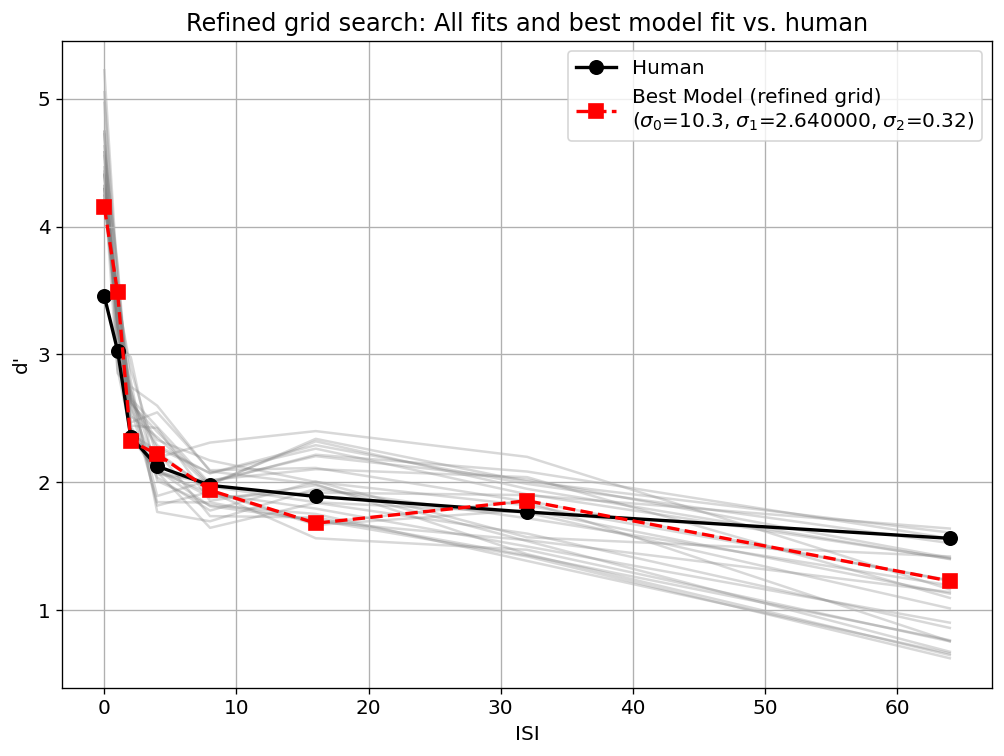

In [23]:
import matplotlib.pyplot as plt

# Suppose you have human_dprime as the human data vector (from prev cells)
# If not in scope, fetch or define it
if 'human_dprime' not in locals():
    # Suppose human_runs, is_multi, which_isi were already loaded,
    # and compute_human_curve is imported/available.
    # Edit as needed for your workflow.
    human_dprime = compute_human_curve(human_runs, is_multi=True, which_isi=1)

# Compute model dprime curves for all fits from df_refined
model_curves = []
for _, row in df_refined.iterrows():
    curve = [row[f'dprime_isi{isi}'] for isi in ISI_VALUES]
    model_curves.append(curve)
model_curves = np.array(model_curves)

# Find best fit in df_refined
def dist_to_human(row, human_dprime):
    model_vec = np.array([row[f'dprime_isi{isi}'] for isi in ISI_VALUES])
    if len(model_vec) != len(human_dprime):
        minlen = min(len(model_vec), len(human_dprime))
        model_vec = model_vec[:minlen]
        hum = human_dprime[:minlen]
    else:
        hum = human_dprime
    return np.linalg.norm(model_vec - hum)

df_refined['dist_to_human'] = df_refined.apply(lambda row: dist_to_human(row, human_dprime), axis=1)
best_row = df_refined.loc[df_refined['dist_to_human'].idxmin()]
best_model_fit = np.array([best_row[f'dprime_isi{isi}'] for isi in ISI_VALUES])


plt.figure(figsize=(10,7))
# Plot all model fits (light gray lines)
for curve in model_curves:
    plt.plot(ISI_VALUES, curve, color='gray', alpha=0.3, zorder=1)
# Plot human and best fit
plt.plot(ISI_VALUES, human_dprime, 'o-k', label='Human', linewidth=2, markersize=8, zorder=2)
best_params = f"$\sigma_0$={best_row['sigma0']}, $\sigma_1$={best_row['sigma1']:3f}, $\sigma_2$={best_row['sigma2']:4.2f}"
plt.plot(ISI_VALUES, best_model_fit, 's--r', 
         label=f"Best Model (refined grid)\n({best_params})", 
         linewidth=2, markersize=8, zorder=3)
plt.xlabel('ISI')
plt.ylabel("d'")
plt.title('Refined grid search: All fits and best model fit vs. human')
plt.legend()
plt.grid(True)
plt.show()

## 7. Verify: run_mc_dprime matches manual computation

In [37]:
# Run the same triple via run_mc_dprime
test_s0, test_s1, test_s2 = 0.3, 0.1, 0.05
test_seed = 99
test_nmc = 2

dp_func, _ = run_mc_dprime(
    test_s0, test_s1, test_s2,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list,
    t_step=t_step,
    isi_values=tuple(ISI_VALUES),
    n_mc=test_nmc,
    seed=test_seed,
    metric=metric,
)

# Manual computation with same params
schedule = make_noise_schedule('three-regime', {
    'sigma0': test_s0, 'sigma1': test_s1, 'sigma2': test_s2, 't_step': t_step,
})
runner_isis = [isi + 1 for isi in ISI_VALUES]
manual_hits = defaultdict(list)
manual_fas = []

for rep in range(test_nmc):
    run = run_model_core(
        sigma0=test_s0,
        X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list,
        noise_schedule=schedule,
        metric=metric,
        seed=test_seed * 10_000 + rep,
    )
    for risi in runner_isis:
        manual_hits[risi].extend(run['isi_hit_dists'].get(risi, []))
    manual_fas.extend(run['fas'])

fas_arr = np.array(manual_fas, dtype=float)
st = 'distance' if metric != 'loglikelihood' else 'likelihood'

dp_manual = {}
for exp_isi, risi in zip(ISI_VALUES, runner_isis):
    hr = manual_hits.get(risi, [])
    if len(hr) < 3:
        dp_manual[exp_isi] = np.nan
        continue
    hs = np.array([s for s, t in hr], dtype=float)
    roc = roc_from_arrays(hs, fas_arr, score_type=st)
    if roc is not None:
        _, _, auc_val = roc
        dp_manual[exp_isi] = auroc_to_dprime(auc_val)
    else:
        dp_manual[exp_isi] = np.nan

print('Comparison: run_mc_dprime vs manual')
print(f'{"ISI":>5} {"run_mc_dprime":>15} {"manual":>15} {"match":>8}')
print('-' * 45)
for isi in ISI_VALUES:
    v1 = dp_func.get(isi, np.nan)
    v2 = dp_manual.get(isi, np.nan)
    match = np.isclose(v1, v2, atol=1e-6) or (np.isnan(v1) and np.isnan(v2))
    print(f"{isi:5d} {v1:15.6f} {v2:15.6f} {'OK' if match else 'MISMATCH':>8}")

Comparison: run_mc_dprime vs manual
  ISI   run_mc_dprime          manual    match
---------------------------------------------
    0        6.722357        6.722357       OK
    1        6.722357        6.722357       OK
    2        6.722357        6.722357       OK
    4        6.722357        6.722357       OK
    8        6.722357        6.722357       OK
   16        6.722357        6.722357       OK
   32        6.722357        6.722357       OK
   64        5.546207        5.546207       OK


## Summary

If all cells ran without error:
- Real stimulus encoding via ResNet50 layer4 works
- `run_model_core` + `ThreeRegimeNoise` produces hits/FAs with expected ISI structure
- d' is positive and generally decreases with ISI
- `run_mc_dprime()` matches manual computation exactly
- The grid search is ready for SLURM deployment